# Параметрический монтаж электродов на руках: геометрия контакта и проверка взаимности

**Научный статус:** вычислительный эксперимент в рамках разработки
методики ТТРКГ. Полученные результаты подтверждают техническую
работоспособность прямой конечно-элементной модели, но не являются
экспериментальной, физиологической или клинической валидацией.

Цель расчёта состоит в проверке трёх вопросов:

1. можно ли воспроизводимо задавать положение четырёх электродов на
   искусственных продолжениях рук через расстояния, измеряемые от
   туловища;
2. насколько изменяется передаточный импеданс при четырёх разных
   способах задания контакта;
3. выполняется ли теорема взаимности при перестановке токовой и
   измерительной пар.

Рассматриваются поверхностный диск диаметром 5 мм, кольцевой электрод
шириной 5 мм, широкая поверхностная манжета и идеализированная внутренняя
поверхность, совпадающая с поперечным сечением руки. Последний вариант
служит численным тестом и не соответствует реально наклеиваемому
электроду.

**Уточнение постановки от 08.09.2026.** По решению автора плоскостными могут быть только наружные токовые электроды I+/I−; внутренние V+/V− должны быть манжетными. Четырёхплоскостная ветка сохранённых ниже результатов не соответствует этой постановке и оставлена для прослеживаемости. Исправленный монтаж с внутренними манжетами 5 мм и новая матрица проводимостей представлены в [ноутбуке 40.05](40.05_Чувствительность_ТТРКГ_к_проводимости_тканей.ipynb). Исторические числа здесь не выдаются за пересчёт исправленной схемы.

## Исходные данные и доказательный статус

Ноутбук не повторяет решение прямой задачи в Python. Он читает
канонические результаты MATLAB/EIDORS, машинный паспорт принятой сетки и
сведения о подготовленной КТ-геометрии из папки
`MATLAB_TRKG4_real_subjects/output`.

Непосредственно измеренный физиологический сигнал в этом расчёте не
используется. Значения импеданса являются результатами математической
модели при заданных геометрии, проводимостях и граничных условиях.
Входные файлы находятся вне Git, поэтому сохранённые результаты
доступны в настоящем отчёте, а полный повторный расчёт требует локальной
расчётной среды и принятых STL/MSH-файлов. Текущая версия MATLAB-кода ещё
содержит незафиксированные изменения; до отдельного коммита точная
воспроизводимость по одному идентификатору Git не обеспечена.

In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 6)

_superscript = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")

def decimal_ru(value, digits=6):
    return f"{float(value):.{digits}f}".replace(".", ",")

def scientific_ru(value, digits=3):
    value = float(value)
    if value == 0:
        return "0"
    exponent = int(math.floor(math.log10(abs(value))))
    mantissa = value / (10 ** exponent)
    return f"{mantissa:.{digits}f}".replace(".", ",") + "·10" + str(exponent).translate(_superscript)

def locate_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "MATLAB_TRKG4_real_subjects").is_dir() and (candidate / "Colab Notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с папками MATLAB_TRKG4_real_subjects и Colab Notebooks")

PROJECT_ROOT = locate_project_root()
MATLAB_ROOT = PROJECT_ROOT / "MATLAB_TRKG4_real_subjects"
OUTPUT = MATLAB_ROOT / "output"

paths = {
    "Геометрия КТ/STL": OUTPUT / "nik_stl_preparation_report.json",
    "Результаты 16 сценариев": OUTPUT / "nik_trkg4_arm_electrode_model_tests_summary.csv",
    "Фактические патчи электродов": OUTPUT / "nik_trkg4_arm_electrode_model_tests_patches.csv",
    "Контракт электрической модели": OUTPUT / "nik_trkg4_arm_electrode_model_tests_contract.json",
    "Приёмка сетки": OUTPUT / "accepted_arm_parameter_mesh_acceptance.json",
}
missing = [label for label, path in paths.items() if not path.is_file()]
if missing:
    raise FileNotFoundError("Отсутствуют обязательные входы: " + ", ".join(missing))

stl_records = json.loads(paths["Геометрия КТ/STL"].read_text(encoding="utf-8"))
summary = pd.read_csv(paths["Результаты 16 сценариев"])
patches = pd.read_csv(paths["Фактические патчи электродов"])
contract = json.loads(paths["Контракт электрической модели"].read_text(encoding="utf-8"))
acceptance = json.loads(paths["Приёмка сетки"].read_text(encoding="utf-8"))

expected_kinds = {
    "point_disc_5mm",
    "circumferential_ring",
    "wide_cuff_equivalent_area",
    "cross_section_plane",
}
assert len(summary) == 16
assert set(summary["electrode_kind"]) == expected_kinds
assert len(patches) == 64
assert bool(summary["reciprocity_pass"].all())
assert acceptance["physical_validation"] is False

input_status = pd.DataFrame({
    "Вход": list(paths),
    "Найден": ["да" if path.is_file() else "нет" for path in paths.values()],
    "Роль": [
        "геометрическая точка отсчёта и радиусы рук",
        "передаточный импеданс и взаимность",
        "фактическое положение и площадь электродов",
        "проводимости и параметры прямой задачи",
        "контроль качества объёмной сетки и границы применимости",
    ],
})
display(input_status)


,Вход,Найден,Роль
0,Геометрия КТ/STL,да,геометрическая точка отсчёта и радиусы рук
1,Результаты 16 сценариев,да,передаточный импеданс и взаимность
2,Фактические патчи электродов,да,фактическое положение и площадь электродов
3,Контракт электрической модели,да,проводимости и параметры прямой задачи
4,Приёмка сетки,да,контроль качества объёмной сетки и границы при...


## Параметрическое задание положения электродов

Для правой руки координаты потенциального и токового электродов задаются
выражениями

$$
x_{V+}=x_{0,R}+d_{\mathrm{in}},\qquad
x_{I+}=x_{V+}+d_{\mathrm{out}},
$$

где $x_{0,R}$ — координата модельной плоскости соединения правой руки с
туловищем; $d_{\mathrm{in}}$ — расстояние от этой плоскости до
внутреннего потенциального электрода; $d_{\mathrm{out}}$ — расстояние
от потенциального электрода до наружного токового электрода.

Для левой руки направление продольной оси противоположно:

$$
x_{V-}=x_{0,L}-d_{\mathrm{in}},\qquad
x_{I-}=x_{V-}-d_{\mathrm{out}},
$$

где $x_{0,L}$ — координата модельной плоскости соединения левой руки с
туловищем; остальные обозначения имеют тот же смысл. Плоскости
$x_{0,R}$ и $x_{0,L}$ обеспечивают воспроизводимую модельную точку
отсчёта, но пока не сопоставлены с анатомическим ориентиром реального
эксперимента.

В расчёте использованы значения $d_{\mathrm{in}}=20$ и 40 мм, а также
$d_{\mathrm{out}}=80$ и 100 мм. Таким образом, для каждого способа
задания контакта рассмотрены четыре положения.

,Метка,Сторона,"x, мм",Тип
0,I+,Правая,"286,560",Токовый
1,V+,Правая,"206,560",Потенциальный
2,V−,Левая,"-225,432",Потенциальный
3,I−,Левая,"-305,432",Токовый


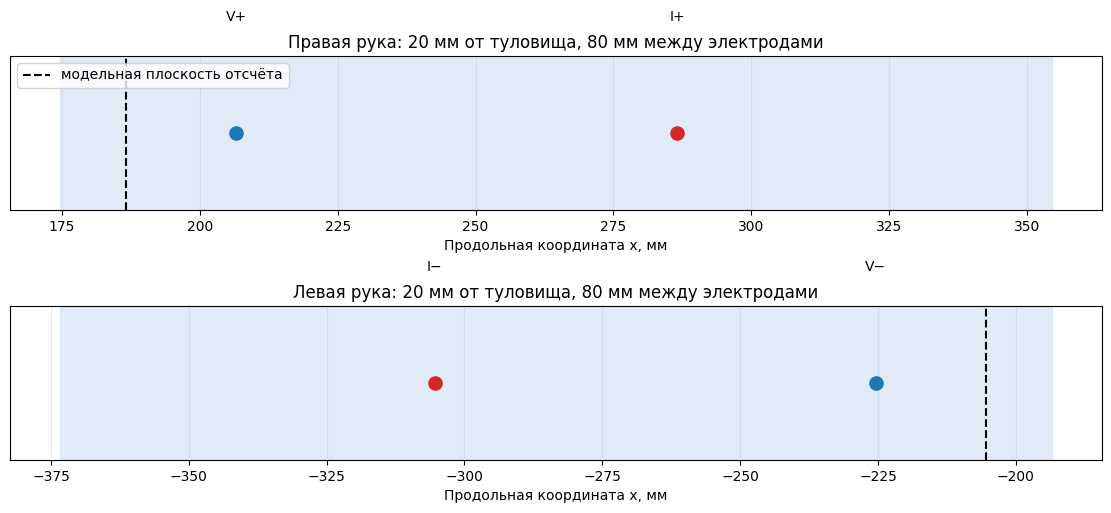

In [2]:
body = next(record for record in stl_records if record["name"] == "body")
arms = body["arm_extension"]

def positions_for(d_in, d_out):
    right = arms["right"]
    left = arms["left"]
    return pd.DataFrame([
        {"Метка": "I+", "Сторона": "Правая", "x, мм": right["cut_x"] + d_in + d_out, "Тип": "Токовый"},
        {"Метка": "V+", "Сторона": "Правая", "x, мм": right["cut_x"] + d_in, "Тип": "Потенциальный"},
        {"Метка": "V−", "Сторона": "Левая", "x, мм": left["cut_x"] - d_in, "Тип": "Потенциальный"},
        {"Метка": "I−", "Сторона": "Левая", "x, мм": left["cut_x"] - d_in - d_out, "Тип": "Токовый"},
    ])

default_positions = positions_for(20.0, 80.0)
position_table = default_positions.copy()
position_table["x, мм"] = position_table["x, мм"].map(lambda value: decimal_ru(value, 3))
display(position_table)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), constrained_layout=True)
for axis, side_key, side_label in zip(axes, ["right", "left"], ["Правая рука", "Левая рука"]):
    arm = arms[side_key]
    axis.axvspan(arm["cylinder_x_min"], arm["cylinder_x_max"], color="#d9e7f5", alpha=0.8)
    axis.axvline(arm["cut_x"], color="black", linestyle="--", label="модельная плоскость отсчёта")
    subset = default_positions[default_positions["Сторона"] == side_label.split()[0]]
    for _, row in subset.iterrows():
        color = "#d62728" if row["Тип"] == "Токовый" else "#1f77b4"
        axis.scatter(row["x, мм"], 0, s=90, color=color, zorder=3)
        axis.text(row["x, мм"], 0.08, row["Метка"], ha="center", fontsize=10)
    axis.set_yticks([])
    axis.set_xlabel("Продольная координата x, мм")
    axis.set_title(f"{side_label}: 20 мм от туловища, 80 мм между электродами")
    axis.grid(axis="x", alpha=0.25)
axes[0].legend(loc="upper left")
plt.show()


## Четыре модели контакта

**Поверхностный диск диаметром 5 мм.** Диск располагается сверху на
цилиндрической поверхности руки. Конечная площадь контакта используется
вместо узлового источника, чтобы избежать сингулярности математической
точки и чрезмерной зависимости от шага сетки.

**Кольцевой электрод шириной 5 мм.** Контакт охватывает руку по
окружности; его внутренний диаметр равен локальному диаметру модельной
руки. Это поверхностный электрод.

**Широкая поверхностная манжета.** Площадь её боковой поверхности
приравнена к площади поперечного сечения руки:

$$
2\pi Rw=\pi R^2,\qquad w=\frac{R}{2},
$$

где $R$ — радиус искусственного продолжения руки, равный 30 мм; $w$ —
ширина манжеты. Номинальная ширина составляет 15 мм. Эта манжета не
является поперечным срезом.

**Идеализированная внутренняя поперечная поверхность.** Целевая
поверхность имеет нулевую толщину и площадь $\pi R^2$. В принятой
тетраэдральной сетке она представлена общими внутренними гранями
элементов, расположенных по разные стороны от заданного сечения. Ткань
при построении поверхности не удаляется. Такой контакт является
сеточно-зависимым численным тестом и физически не устанавливается на
руку.

In [3]:
kind_labels = {
    "point_disc_5mm": "Поверхностный диск 5 мм",
    "circumferential_ring": "Кольцевой электрод 5 мм",
    "wide_cuff_equivalent_area": "Широкая манжета 15 мм",
    "cross_section_plane": "Внутренняя поперечная поверхность",
}
kind_order = list(kind_labels)

geometry_rows = []
nominal_widths = {
    "point_disc_5mm": 5.0,
    "circumferential_ring": 5.0,
    "wide_cuff_equivalent_area": float(contract["wide_cuff_nominal_width_mm"]),
    "cross_section_plane": float(contract["cross_section_plane_nominal_thickness_mm"]),
}
for kind in kind_order:
    subset = patches[patches["electrode_kind"] == kind].copy()
    spans = subset["patch_x_max_mm"] - subset["patch_x_min_mm"]
    projected = subset["projected_cross_section_area_ratio"].dropna()
    geometry_rows.append({
        "Модель контакта": kind_labels[kind],
        "Номинальный продольный размер, мм": nominal_widths[kind],
        "Диапазон фактического размера по x, мм": f"{spans.min():.4f}–{spans.max():.4f}".replace(".", ","),
        "Номинальная площадь, мм²": decimal_ru(subset["nominal_area_mm2"].mean(), 3),
        "Отношение площади граней к номинальной": f"{subset['area_ratio'].min():.4f}–{subset['area_ratio'].max():.4f}".replace(".", ","),
        "Отношение проекционной площади к номинальной": (
            f"{projected.min():.4f}–{projected.max():.4f}".replace(".", ",") if len(projected) else "не применяется"
        ),
    })

geometry_summary = pd.DataFrame(geometry_rows)
geometry_summary["Номинальный продольный размер, мм"] = geometry_summary["Номинальный продольный размер, мм"].map(lambda value: decimal_ru(value, 1))
display(geometry_summary)


,Модель контакта,"Номинальный продольный размер, мм","Диапазон фактического размера по x, мм","Номинальная площадь, мм²",Отношение площади граней к номинальной,Отношение проекционной площади к номинальной
0,Поверхностный диск 5 мм,"5,0","4,9839–5,9810","19,635","1,0125–1,0379",не применяется
1,Кольцевой электрод 5 мм,"5,0","4,9839–4,9842","942,478","0,9967–0,9968",не применяется
2,Широкая манжета 15 мм,"15,0","14,9516–14,9525","2827,433","0,9967–0,9968",не применяется
3,Внутренняя поперечная поверхность,"0,0","2,0373–2,2587","2827,433","1,5663–1,6335","1,0109–1,0170"


## Интерактивная визуализация электродов и расчётных результатов

Интерактивный отчёт объединяет геометрию и численные результаты всех 16
сценариев настоящего ноутбука. Пользователь может независимо выбрать
расстояние внутреннего электрода от туловища, расстояние между внутренним и
наружным электродами и один из четырёх способов задания контакта. На
трёхмерной модели одновременно показаны электроды $I+$, $V+$, $V-$ и $I-$.

Для выбранного сценария отображаются прямой и взаимный передаточные импедансы,
относительная ошибка взаимности и отношение результата к импедансу дискового
контакта диаметром 5 мм. Ниже приведены полная таблица 16 сценариев, состав
расчётной области, проводимости, удельные сопротивления и число элементов,
получивших каждый тканевой класс.

Интерактивное представление читает те же таблицы и контракт MATLAB/EIDORS,
которые использованы в предшествующих разделах. Оно не выполняет отдельный
расчёт и не является дополнительным источником численных данных. Поверхность
тела упрощена только для вращения в браузере; результаты импеданса получены на
полной принятой сетке из 4 358 825 тетраэдров.

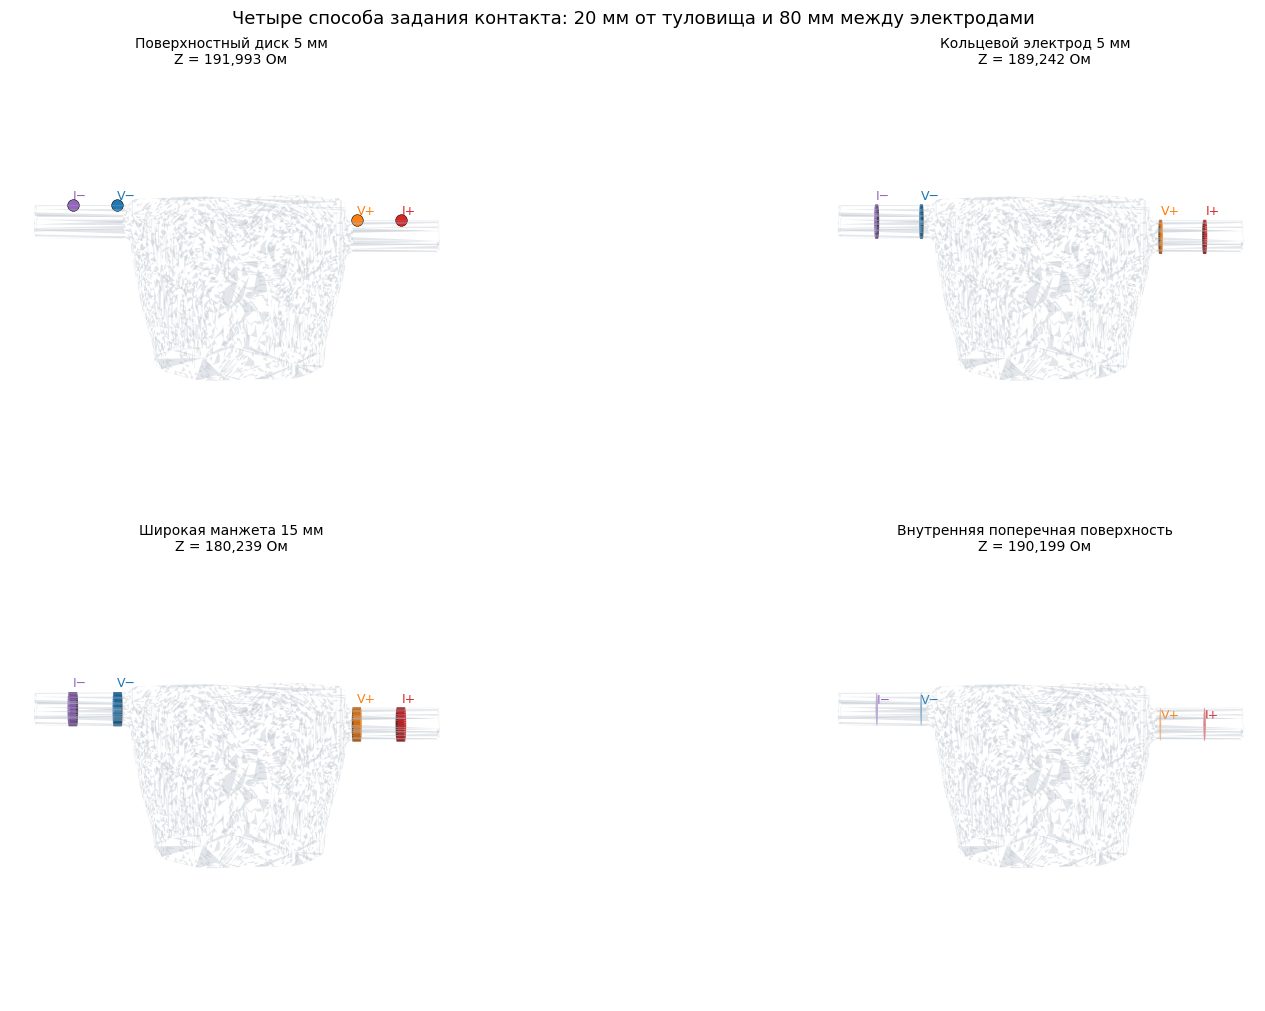

In [4]:
# Сохранённый статический обзор: виден даже в просмотрщиках без iframe и JavaScript
import html as html_stdlib
import json as json_stdlib
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pathlib import Path

ARM_VIEWER_RELATIVE_URL = "40.02_Интерактивная_визуализация_электродов_на_руках.html"
viewer_candidates = [
    Path(ARM_VIEWER_RELATIVE_URL),
    Path("Colab Notebooks") / ARM_VIEWER_RELATIVE_URL,
]
viewer_path = next(
    (candidate.resolve() for candidate in viewer_candidates if candidate.exists()),
    None,
)
if viewer_path is None:
    raise FileNotFoundError("Не найден интерактивный отчёт по электродам на руках")

outer_html = viewer_path.read_text(encoding="utf-8")
srcdoc_match = __import__("re").search(
    r'srcdoc="(.*)"\s*>\s*</iframe>', outer_html, flags=__import__("re").DOTALL
)
if srcdoc_match is None:
    raise ValueError("В интерактивном отчёте не найден встроенный документ srcdoc")
inner_html = html_stdlib.unescape(srcdoc_match.group(1))
data_start = inner_html.index("const DATA = ") + len("const DATA = ")
viewer_data, _ = json_stdlib.JSONDecoder().raw_decode(inner_html[data_start:])

vertices = np.asarray(viewer_data["mesh"]["vertices"], dtype=float).reshape(-1, 3)
faces = np.asarray(viewer_data["mesh"]["faces"], dtype=int).reshape(-1, 3)
viewer_results = pd.DataFrame(viewer_data["results"])
viewer_patches = pd.DataFrame(viewer_data["patches"])

preview_inner = 20
preview_outer = 80
preview_kinds = [
    "point_disc_5mm",
    "circumferential_ring",
    "wide_cuff_equivalent_area",
    "cross_section_plane",
]
role_colours = {
    "I_plus": "#d62728",
    "V_plus": "#ff7f0e",
    "V_minus": "#1f77b4",
    "I_minus": "#9467bd",
}
role_labels = {"I_plus": "I+", "V_plus": "V+", "V_minus": "V−", "I_minus": "I−"}

def draw_cylinder_contact(axis, row, radius=30.8):
    theta = np.linspace(0, 2 * np.pi, 48)
    xmin, xmax = float(row["xmin"]), float(row["xmax"])
    xx = np.vstack([np.full_like(theta, xmin), np.full_like(theta, xmax)])
    yy = float(row["y"]) + radius * np.cos(theta)[None, :]
    zz = float(row["z"] - 30.0) + radius * np.sin(theta)[None, :]
    axis.plot_surface(xx, yy, zz, color=role_colours[row["role"]], alpha=0.92, linewidth=0)

def draw_cross_section(axis, row, radius=30.0):
    theta = np.linspace(0, 2 * np.pi, 40, endpoint=False)
    centre = np.array([float(row["xcentroid"]), float(row["y"]), float(row["z"])])
    rim = np.column_stack([
        np.full_like(theta, centre[0]),
        centre[1] + radius * np.cos(theta),
        centre[2] + radius * np.sin(theta),
    ])
    triangles = [[centre, rim[index], rim[(index + 1) % len(rim)]] for index in range(len(rim))]
    axis.add_collection3d(Poly3DCollection(
        triangles,
        facecolor=role_colours[row["role"]],
        edgecolor="none",
        alpha=0.72,
    ))

figure = plt.figure(figsize=(16, 10), constrained_layout=True)
body_faces = faces[::4]
for panel, kind in enumerate(preview_kinds, start=1):
    axis = figure.add_subplot(2, 2, panel, projection="3d")
    axis.add_collection3d(Poly3DCollection(
        vertices[body_faces],
        facecolor="#aeb8c2",
        edgecolor="none",
        alpha=0.34,
    ))
    selected = viewer_patches[
        (viewer_patches["kind"] == kind)
        & (viewer_patches["key"] == f"{preview_inner}|{preview_outer}|{kind}")
    ]
    for _, row in selected.iterrows():
        if kind == "point_disc_5mm":
            axis.scatter(
                [row["x"]], [row["y"]], [row["z"] + 0.55],
                s=70, color=role_colours[row["role"]], edgecolor="black", linewidth=0.4,
            )
        elif kind == "cross_section_plane":
            draw_cross_section(axis, row)
        else:
            draw_cylinder_contact(axis, row)
        axis.text(
            float(row["x"]), float(row["y"] - 8), float(row["z"] + 13),
            role_labels[row["role"]], color=role_colours[row["role"]], fontsize=9,
        )

    result = viewer_results[
        (viewer_results["kind"] == kind)
        & (viewer_results["inner"] == preview_inner)
        & (viewer_results["outer"] == preview_outer)
    ].iloc[0]
    axis.set_title(
        f"{kind_labels[kind]}\n"
        f"Z = {decimal_ru(result['zDirect'], 3)} Ом",
        fontsize=10,
    )
    axis.set_xlim(vertices[:, 0].min(), vertices[:, 0].max())
    axis.set_ylim(vertices[:, 1].min(), vertices[:, 1].max())
    axis.set_zlim(vertices[:, 2].min(), vertices[:, 2].max())
    axis.set_box_aspect(np.ptp(vertices, axis=0))
    axis.view_init(elev=14, azim=-90)
    axis.set_axis_off()

figure.suptitle(
    "Четыре способа задания контакта: 20 мм от туловища и 80 мм между электродами",
    fontsize=13,
)
plt.show()

In [5]:
from pathlib import Path
from IPython.display import HTML, IFrame, display

ARM_VIEWER_RELATIVE_URL = "40.02_Интерактивная_визуализация_электродов_на_руках.html"
viewer_candidates = [
    Path(ARM_VIEWER_RELATIVE_URL),
    Path("Colab Notebooks") / ARM_VIEWER_RELATIVE_URL,
]
viewer_path = next(
    (candidate.resolve() for candidate in viewer_candidates if candidate.exists()),
    None,
)
if viewer_path is None:
    raise FileNotFoundError(
        "Не найден соседний интерактивный HTML-файл 40.02. "
        "Восстановите его из канонического артефакта MATLAB-моделирования."
    )

display(HTML(
    f'<p><a href="{ARM_VIEWER_RELATIVE_URL}" target="_blank" rel="noopener">'
    'Открыть интерактивную модель в отдельной вкладке</a>.</p>'
))
display(IFrame(
    src=ARM_VIEWER_RELATIVE_URL,
    width="100%",
    height=1350,
))
display(HTML(
    '<p><em>Если просмотрщик запрещает JavaScript или iframe, '
    'используйте сохранённый статический рисунок выше либо откройте соседний HTML по ссылке.</em></p>'
))

## Состав электрической модели

Передаточный импеданс рассчитан для полного объёма тела с
искусственными продолжениями рук, а не для однородного цилиндра.
Мягкие ткани образуют фоновый класс. Лёгкие, сердце целиком и
кортикальная кость назначены по замкнутым STL-маскам на основании
положения центров тетраэдров.

У испытуемого Nix отсутствует отдельная сегментация крови. Поэтому
заданное в конфигурации значение проводимости крови не назначено ни одному
элементу сетки, а вся доступная маска сердца получает единый параметр класса
«сердце целиком». Эта модель не разделяет миокард и внутрисердечную
кровь.

Проводимости заданы действительными скалярными числами на частоте
50 кГц. Комплексная диэлектрическая проницаемость не учитывается;
вследствие этого расчётная мнимая часть импеданса равна нулю. Ток 1 А
используется как линейная нормировка прямой задачи, а не как описание
режима реального прибора.

In [6]:
tissue_labels = {
    "soft_tissue": "Мягкие ткани, фоновый класс",
    "lungs": "Лёгкие",
    "heart": "Сердце целиком",
    "bones": "Кортикальная кость",
    "blood": "Кровь, отдельный класс не назначен",
}
source_labels = {
    "Nik solution clouds / historical MATLAB-Python model calculations": "исторические расчёты MATLAB/Python для Nix",
    "own_solution_cloud": "собственное облако решений проекта",
    "Heart Muscle": "Heart Muscle, IT'IS/Gabriel",
    "Bone (Cortical)": "Bone (Cortical), IT'IS/Gabriel",
    "Blood": "параметр задан, но отдельная маска отсутствует",
}

tissue_rows = []
for tissue in contract["tissues"]:
    tissue_rows.append({
        "Область": tissue_labels[tissue["name"]],
        "Проводимость, См/м": tissue["sigma_s_per_m"],
        "Удельное сопротивление, Ом·м": tissue["rho_ohm_m"],
        "Назначено тетраэдров": int(tissue["assigned_elements"]),
        "STL-маска": "есть" if tissue["mask_available"] else "нет",
        "Основание параметра": source_labels.get(tissue["source"], tissue["source"]),
    })
tissue_table = pd.DataFrame(tissue_rows)
tissue_display = tissue_table.copy()
tissue_display["Проводимость, См/м"] = tissue_display["Проводимость, См/м"].map(lambda value: decimal_ru(value, 6))
tissue_display["Удельное сопротивление, Ом·м"] = tissue_display["Удельное сопротивление, Ом·м"].map(lambda value: decimal_ru(value, 6))
tissue_display["Назначено тетраэдров"] = tissue_display["Назначено тетраэдров"].map(lambda value: f"{int(value):,}".replace(",", " "))
display(tissue_display)

mesh = acceptance["mesh_basic_quality"]
model_settings = pd.DataFrame([
    {"Параметр": "Частота", "Значение": f"{contract['frequency_hz'] / 1000:.0f} кГц"},
    {"Параметр": "Ток", "Значение": f"{contract['current_ampere']:.0f} А, линейная нормировка"},
    {"Параметр": "Удельный контактный импеданс", "Значение": scientific_ru(contract["contact_impedance_ohm_m2"], 6) + " Ом·м²"},
    {"Параметр": "Расчётная сетка", "Значение": f"{mesh['nodes']:,} узлов; {mesh['tetrahedra']:,} тетраэдров".replace(",", " ")},
    {"Параметр": "Объём сетки", "Значение": decimal_ru(mesh["absolute_volume_l"], 6) + " л"},
    {"Параметр": "Инвертированные или вырожденные элементы", "Значение": "отсутствуют"},
])
display(model_settings)


,Область,"Проводимость, См/м","Удельное сопротивление, Ом·м",Назначено тетраэдров,STL-маска,Основание параметра
0,"Мягкие ткани, фоновый класс","0,211498","4,728175",4 342 549,есть,исторические расчёты MATLAB/Python для Nix
1,Лёгкие,"0,057449","17,406700",11 856,есть,собственное облако решений проекта
2,Сердце целиком,"0,195435","5,116784",1 963,есть,"Heart Muscle, IT'IS/Gabriel"
3,Кортикальная кость,"0,020642","48,445126",2 457,есть,"Bone (Cortical), IT'IS/Gabriel"
4,"Кровь, отдельный класс не назначен","0,700801","1,426939",0,нет,"параметр задан, но отдельная маска отсутствует"


,Параметр,Значение
0,Частота,50 кГц
1,Ток,"1 А, линейная нормировка"
2,Удельный контактный импеданс,"1,591549·10⁻⁴ Ом·м²"
3,Расчётная сетка,752 827 узлов; 4 358 825 тетраэдров
4,Объём сетки,"20,171521 л"
5,Инвертированные или вырожденные элементы,отсутствуют


## Передаточный импеданс и теорема взаимности

Рассчитываемая величина определяется выражением

$$
Z_{\mathrm{tr}}=\frac{U_{V+}-U_{V-}}{I},
$$

где $Z_{\mathrm{tr}}$ — передаточный импеданс; $U_{V+}$ и $U_{V-}$ —
потенциалы измерительных электродов; $I$ — ток, задаваемый между
электродами $I+$ и $I-$.

Для линейной пассивной среды со скалярной проводимостью и неизменной
моделью контакта должна выполняться теорема взаимности:

$$
Z_{I^+I^-,\,V^+V^-}=Z_{V^+V^-,\,I^+I^-},
$$

где левая часть соответствует исходному расположению токовой и
измерительной пар, а правая — расчёту после их перестановки без
изменения полярности каждой пары.

В численной проверке используется критерий

$$
|Z_{\mathrm{dir}}-Z_{\mathrm{rec}}|\leq
10^{-10}\ \text{Ом}+10^{-8}\max(|Z_{\mathrm{dir}}|,|Z_{\mathrm{rec}}|),
$$

где $Z_{\mathrm{dir}}$ — результат прямого расчёта;
$Z_{\mathrm{rec}}$ — результат взаимного расчёта; $10^{-10}$ Ом и
$10^{-8}$ — принятые абсолютный и относительный вычислительные допуски.
Выполнение критерия проверяет внутреннюю согласованность реализации, но
не подтверждает физиологическую правильность модели.

,"Расстояние от туловища, мм","Расстояние между электродами, мм",Модель контакта,"Z, Ом","Z после перестановки пар, Ом",Относительная ошибка взаимности,Отношение к диску 5 мм
0,20,80,Поверхностный диск 5 мм,"191,993105","191,993105","5,921·10⁻¹⁶","1,000000"
1,20,80,Кольцевой электрод 5 мм,"189,241705","189,241705","4,506·10⁻¹⁶","0,985669"
2,20,80,Широкая манжета 15 мм,"180,239071","180,239071","3,154·10⁻¹⁶","0,938779"
3,20,80,Внутренняя поперечная поверхность,"190,198977","190,198977","1,494·10⁻¹⁶","0,990655"
4,20,100,Поверхностный диск 5 мм,"191,583804","191,583804","2,967·10⁻¹⁶","1,000000"
5,20,100,Кольцевой электрод 5 мм,"189,241274","189,241274","3,004·10⁻¹⁶","0,987773"
6,20,100,Широкая манжета 15 мм,"180,238492","180,238492","3,154·10⁻¹⁶","0,940781"
7,20,100,Внутренняя поперечная поверхность,"190,198977","190,198977",0,"0,992772"
8,40,80,Поверхностный диск 5 мм,"259,472058","259,472058",0,"1,000000"
9,40,80,Кольцевой электрод 5 мм,"258,246930","258,246930","2,201·10⁻¹⁶","0,995278"


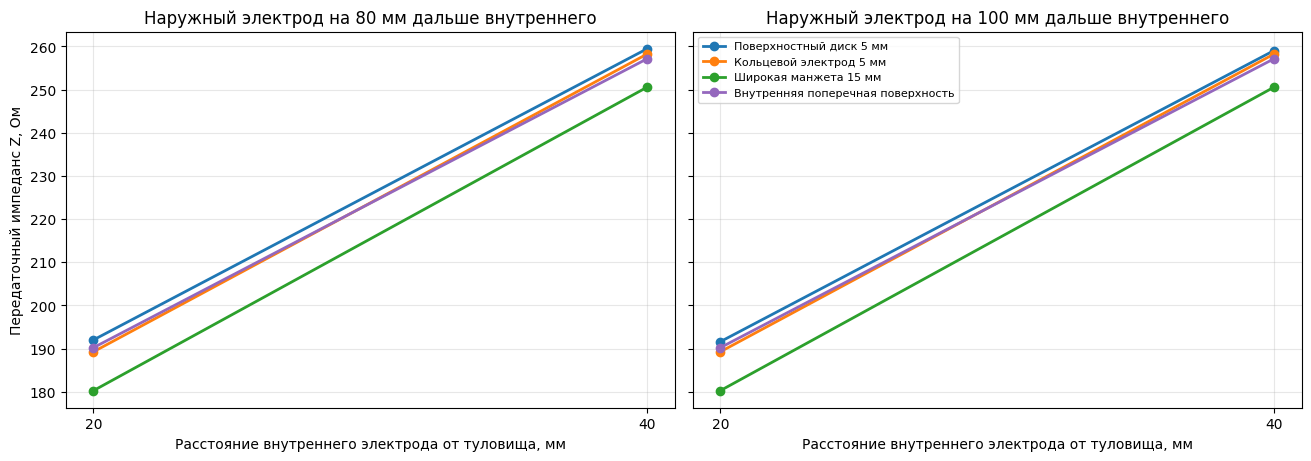

In [7]:
summary = summary.copy()
summary["Модель контакта"] = summary["electrode_kind"].map(kind_labels)
summary["Расстояние от туловища, мм"] = summary["inner_from_trunk_mm"].astype(int)
summary["Расстояние между электродами, мм"] = summary["outer_from_inner_mm"].astype(int)
summary["Z, Ом"] = summary["Z_direct_real_ohm"]
summary["Z после перестановки пар, Ом"] = summary["Z_reciprocal_real_ohm"]
summary["Относительная ошибка взаимности"] = summary["reciprocity_relative_error"]
summary["Отношение к диску 5 мм"] = summary["magnitude_ratio_to_point_disc"]
summary["_kind_order"] = summary["electrode_kind"].map({kind: index for index, kind in enumerate(kind_order)})
summary = summary.sort_values(["inner_from_trunk_mm", "outer_from_inner_mm", "_kind_order"])

result_table = summary[[
    "Расстояние от туловища, мм",
    "Расстояние между электродами, мм",
    "Модель контакта",
    "Z, Ом",
    "Z после перестановки пар, Ом",
    "Относительная ошибка взаимности",
    "Отношение к диску 5 мм",
]].reset_index(drop=True)
result_display = result_table.copy()
result_display["Z, Ом"] = result_display["Z, Ом"].map(lambda value: decimal_ru(value, 6))
result_display["Z после перестановки пар, Ом"] = result_display["Z после перестановки пар, Ом"].map(lambda value: decimal_ru(value, 6))
result_display["Относительная ошибка взаимности"] = result_display["Относительная ошибка взаимности"].map(lambda value: scientific_ru(value, 3))
result_display["Отношение к диску 5 мм"] = result_display["Отношение к диску 5 мм"].map(lambda value: decimal_ru(value, 6))
display(result_display)

colors = {
    "point_disc_5mm": "#1f77b4",
    "circumferential_ring": "#ff7f0e",
    "wide_cuff_equivalent_area": "#2ca02c",
    "cross_section_plane": "#9467bd",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True, constrained_layout=True)
for axis, outer_distance in zip(axes, [80, 100]):
    subset = summary[summary["outer_from_inner_mm"] == outer_distance]
    for kind in kind_order:
        group = subset[subset["electrode_kind"] == kind].sort_values("inner_from_trunk_mm")
        axis.plot(
            group["inner_from_trunk_mm"],
            group["Z_direct_real_ohm"],
            "o-",
            linewidth=2,
            label=kind_labels[kind],
            color=colors[kind],
        )
    axis.set_title(f"Наружный электрод на {outer_distance} мм дальше внутреннего")
    axis.set_xlabel("Расстояние внутреннего электрода от туловища, мм")
    axis.set_xticks([20, 40])
    axis.grid(alpha=0.3)
axes[0].set_ylabel("Передаточный импеданс Z, Ом")
axes[1].legend(loc="best", fontsize=8)
plt.show()


## Сопоставление кольцевого электрода и внутренней поперечной поверхности

Вопрос о том, почему импеданс внутренней поверхности может оказаться
больше импеданса кольцевого электрода, нельзя решать только по площади
контакта. В четырёхэлектродной постановке рассчитывается передаточный
импеданс, определяемый распределением тока в объёме и способом
усреднения потенциала измерительными электродами.

Далее внутреннюю поперечную поверхность для краткости называют срезом.
Кольцевой электрод вводит ток с поверхности руки и усредняет потенциал
по её окружности. Внутренняя поверхность делает эквипотенциальным всё
поперечное сечение и усредняет потенциал по внутренним и периферическим
областям одновременно. Эти граничные условия формируют разные поля;
поэтому увеличение площади контакта не задаёт однозначного направления
изменения $Z_{\mathrm{tr}}$.

Для сопоставления масштаба контактного параметра дополнительно вычисляется
отношение $z_c/A$, где $z_c$ — удельный контактный импеданс, а $A$ —
номинальная площадь контакта. Эта диагностическая оценка не является
самостоятельной моделью передаточного импеданса.

,"Расстояние от туловища, мм","Расстояние между электродами, мм","Z кольца, Ом","Z внутреннего среза, Ом","Разность импедансов (срез − кольцо), Ом","Относительная разность, %"
0,20,80,"189,241705","190,198977","0,957273","0,505847"
1,20,100,"189,241274","190,198977","0,957703","0,506075"
2,40,80,"258,246930","257,153378","-1,093552","-0,423452"
3,40,100,"258,246446","257,153378","-1,093068","-0,423265"


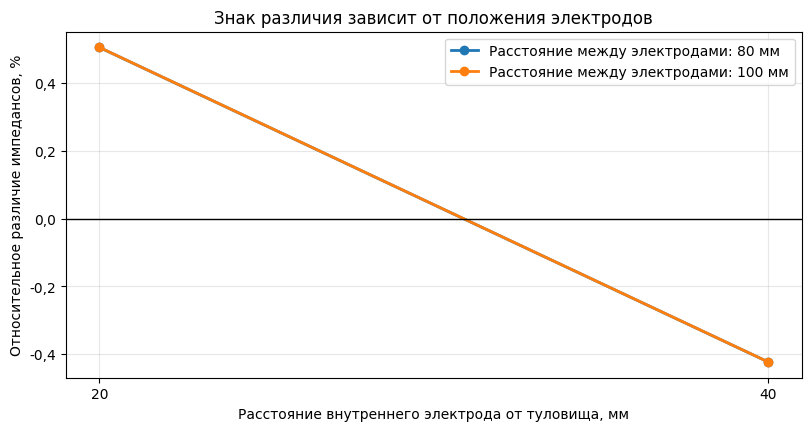

,Модель контакта,"Номинальная площадь, мм²","Оценка контактного масштаба z_c/A, Ом"
0,Кольцевой электрод 5 мм,"942,478","0,168869"
1,Внутренняя поперечная поверхность,"2827,433","0,056290"


In [8]:
pivot = summary.pivot_table(
    index=["inner_from_trunk_mm", "outer_from_inner_mm"],
    columns="electrode_kind",
    values="Z_direct_real_ohm",
    aggfunc="first",
).reset_index()
comparison = pd.DataFrame({
    "Расстояние от туловища, мм": pivot["inner_from_trunk_mm"].astype(int),
    "Расстояние между электродами, мм": pivot["outer_from_inner_mm"].astype(int),
    "Z кольца, Ом": pivot["circumferential_ring"],
    "Z внутреннего среза, Ом": pivot["cross_section_plane"],
})
comparison["Разность импедансов (срез − кольцо), Ом"] = comparison["Z внутреннего среза, Ом"] - comparison["Z кольца, Ом"]
comparison["Относительная разность, %"] = (
    comparison["Разность импедансов (срез − кольцо), Ом"] / comparison["Z кольца, Ом"] * 100
)
comparison_display = comparison.copy()
for column in ["Z кольца, Ом", "Z внутреннего среза, Ом", "Разность импедансов (срез − кольцо), Ом", "Относительная разность, %"]:
    comparison_display[column] = comparison_display[column].map(lambda value: decimal_ru(value, 6))
display(comparison_display)

fig, axis = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
for outer_distance, group in comparison.groupby("Расстояние между электродами, мм"):
    axis.plot(
        group["Расстояние от туловища, мм"],
        group["Относительная разность, %"],
        "o-",
        linewidth=2,
        label=f"Расстояние между электродами: {outer_distance} мм",
    )
axis.axhline(0, color="black", linewidth=1)
axis.set_xticks([20, 40])
axis.set_xlabel("Расстояние внутреннего электрода от туловища, мм")
axis.set_ylabel("Относительное различие импедансов, %")
axis.set_title("Знак различия зависит от положения электродов")
axis.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:.1f}".replace(".", ",")))
axis.grid(alpha=0.3)
axis.legend()
plt.show()

area_by_kind = summary.groupby("electrode_kind")["nominal_contact_area_mean_mm2"].mean()
area_diagnostic = pd.DataFrame({
    "Модель контакта": [kind_labels["circumferential_ring"], kind_labels["cross_section_plane"]],
    "Номинальная площадь, мм²": [area_by_kind["circumferential_ring"], area_by_kind["cross_section_plane"]],
})
area_diagnostic["Оценка контактного масштаба z_c/A, Ом"] = (
    contract["contact_impedance_ohm_m2"]
    / (area_diagnostic["Номинальная площадь, мм²"] * 1e-6)
)
area_display = area_diagnostic.copy()
area_display["Номинальная площадь, мм²"] = area_display["Номинальная площадь, мм²"].map(lambda value: decimal_ru(value, 3))
area_display["Оценка контактного масштаба z_c/A, Ом"] = area_display["Оценка контактного масштаба z_c/A, Ом"].map(lambda value: decimal_ru(value, 6))
display(area_display)


### Интерпретация различий

При расстоянии внутреннего электрода 20 мм импеданс внутреннего среза
больше импеданса кольца приблизительно на 0,51%. При расстоянии 40 мм
соотношение меняется: импеданс среза меньше приблизительно на 0,42%.
Следовательно, расчёт не подтверждает универсальное увеличение
импеданса для поперечного среза. Он показывает небольшое
позиционно-зависимое различие двух граничных условий.

Приведённая в таблице диагностическая оценка $z_c/A$ характеризует только
масштаб контактного импеданса при заданной площади. Она не является
слагаемым, которое можно непосредственно прибавить к передаточному
импедансу четырёхэлектродной схемы. Полученные значения существенно
меньше полного $Z_{\mathrm{tr}}$, составляющего 190–258 Ом; поэтому
различие между моделями нельзя объяснить только площадью контакта. Оно
формируется также распределением поля внутри расчётной области и
способом усреднения потенциала.

Для внутреннего среза изменение расстояния между внутренним и наружным
электродами с 80 до 100 мм не изменило рассчитанный импеданс в пределах
сохранённой точности. Такое поведение согласуется с одномерным пределом
для полного эквипотенциального сечения: дополнительное падение
напряжения возникает вне измерительного интервала. Однако точное
совпадение также зависит от способа построения внутреннего электрода и
пока рассматривается только как диагностический результат модели.

Наконец, внутренняя поверхность аппроксимирована наклонными гранями
тетраэдров. Продольный разброс этих граней составляет 2,037–2,259 мм,
а проекционная площадь равна 1,011–1,017 номинальной площади. Поскольку
различие между срезом и кольцом не превышает 0,51%, его нельзя отделить
от возможного сеточного смещения без отдельного исследования
сходимости.

## Результаты проверки взаимности

Теорема взаимности проверена отдельно для каждого из 16 сценариев.
Максимальная относительная ошибка используется как технический критерий
согласованности прямого и взаимного расчётов. Нулевые значения невозможно
показать на логарифмической оси; только на графике они заменены уровнем
$10^{-18}$. Численные таблицы сохраняют исходные нули.

,Показатель,Значение
0,Число сценариев,16
1,"Сценарии, прошедшие критерий",16
2,Максимальная относительная ошибка,"5,921·10⁻¹⁶"
3,Принятый относительный допуск,"1,0·10⁻⁸"


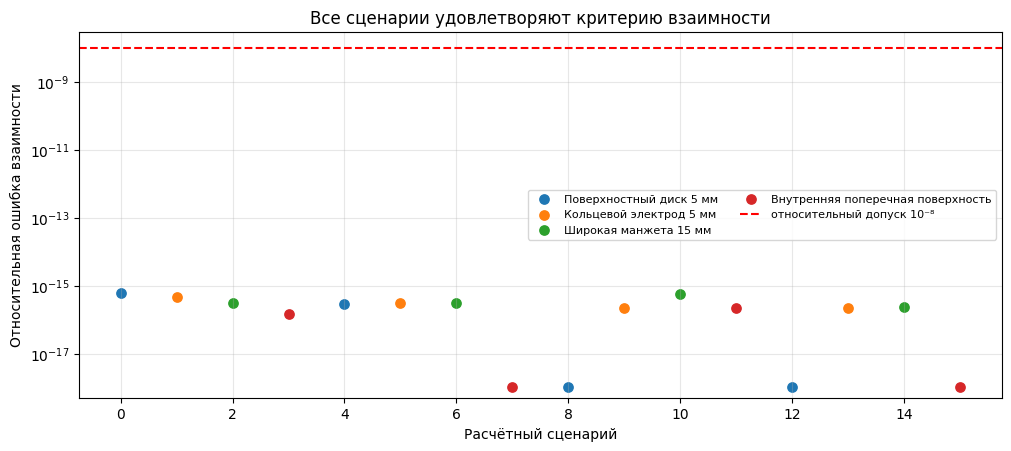

In [9]:
max_error = float(summary["reciprocity_relative_error"].max())
reciprocity_result = pd.DataFrame([
    {"Показатель": "Число сценариев", "Значение": len(summary)},
    {"Показатель": "Сценарии, прошедшие критерий", "Значение": int(summary["reciprocity_pass"].sum())},
    {"Показатель": "Максимальная относительная ошибка", "Значение": scientific_ru(max_error, 3)},
    {"Показатель": "Принятый относительный допуск", "Значение": "1,0·10⁻⁸"},
])
display(reciprocity_result)

fig, axis = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
plot_data = summary.reset_index(drop=True)
plot_data["Ошибка для графика"] = plot_data["reciprocity_relative_error"].clip(lower=1e-18)
x = np.arange(len(plot_data))
for kind in kind_order:
    mask = plot_data["electrode_kind"] == kind
    axis.scatter(x[mask], plot_data.loc[mask, "Ошибка для графика"], s=45, label=kind_labels[kind])
axis.axhline(1e-8, color="red", linestyle="--", label="относительный допуск 10⁻⁸")
axis.set_yscale("log")
axis.set_xlabel("Расчётный сценарий")
axis.set_ylabel("Относительная ошибка взаимности")
axis.set_title("Все сценарии удовлетворяют критерию взаимности")
axis.set_ylim(5e-19, 3e-8)
axis.grid(alpha=0.3)
axis.legend(fontsize=8, ncol=2)
plt.show()


## Перенос положения электродов на поверхность рук

Действующее параметрическое размещение использует продольную координату
искусственной цилиндрической руки. Для проверки возможности перейти от этой
частной координаты к длине вдоль поверхности применён прототип
`surface_path_v1`. Его входами служат треугольная поверхность и направляющие
точки, последовательно выбранные на коже. Между соседними точками строится
кратчайший путь по рёбрам сетки.

Поверхностной координатой электрода называют накопленную длину этого пути от
первого разрешённого узла до центра контакта. Она определяется геометрией и
направляющими точками и не зависит от рассчитанного передаточного импеданса.
Декартовы координаты центра являются результатом привязки к конкретной сетке.

Прототип проверен на синтетических поверхностях и на принятой 1-мм сетке
индивидуальной модели. На сетке сопоставлялись сочетания
$d_{\mathrm{in}}=20$ и 40 мм с $d_{\mathrm{out}}=80$ и 100 мм. Прямое
решение FEM повторно не выполнялось: проверялось только положение центров.
Общий способ выбора координат на поверхности тела, включая свободную и
симметричную расстановку, вынесен в ноутбук `40.03`.

,Электрод,Сторона,"Минимальное расхождение, мм","Максимальное расхождение, мм"
0,I−,Левая,"7,853","7,853"
1,I+,Правая,"2,669","2,669"
2,V−,Левая,"7,853","7,853"
3,V+,Правая,"2,669","4,143"


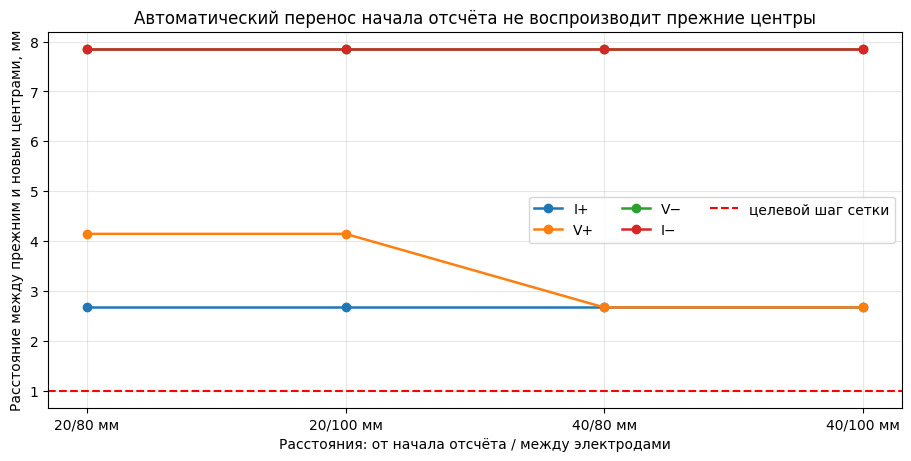

In [10]:
surface_summary_path = OUTPUT / "nik_surface_coordinate_validation.csv"
surface_contract_path = OUTPUT / "nik_surface_coordinate_validation.json"
if not surface_summary_path.is_file() or not surface_contract_path.is_file():
    raise FileNotFoundError(
        "Не выполнена проверка поверхностных координат. "
        "Запустите run_trkg4_surface_coordinate_validation в MATLAB."
    )

surface_summary = pd.read_csv(surface_summary_path)
surface_contract = json.loads(surface_contract_path.read_text(encoding="utf-8"))
assert len(surface_summary) == 16
assert surface_contract["coordinate_system"] == "surface_path_v1"
assert surface_contract["fem_forward_solve_performed"] is False

surface_by_electrode = (
    surface_summary.groupby(["label", "side"], as_index=False)
    .agg(
        minimum_difference_mm=("centre_difference_mm", "min"),
        maximum_difference_mm=("centre_difference_mm", "max"),
    )
)
label_ru = {"I_plus": "I+", "V_plus": "V+", "V_minus": "V−", "I_minus": "I−"}
side_ru = {"right": "Правая", "left": "Левая"}
surface_display = pd.DataFrame({
    "Электрод": surface_by_electrode["label"].map(label_ru),
    "Сторона": surface_by_electrode["side"].map(side_ru),
    "Минимальное расхождение, мм": surface_by_electrode["minimum_difference_mm"].map(lambda value: decimal_ru(value, 3)),
    "Максимальное расхождение, мм": surface_by_electrode["maximum_difference_mm"].map(lambda value: decimal_ru(value, 3)),
})
display(surface_display)

figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
plot_surface = surface_summary.copy()
plot_surface["Сценарий"] = (
    plot_surface["scenario_id"].str.replace("in", "", regex=False)
    .str.replace("_out", "/", regex=False) + " мм"
)
plot_surface["Электрод"] = plot_surface["label"].map(label_ru)
for electrode, group in plot_surface.groupby("Электрод", sort=False):
    axis.plot(
        group["Сценарий"],
        group["centre_difference_mm"],
        "o-",
        linewidth=1.8,
        label=electrode,
    )
axis.axhline(
    surface_contract["mesh_target_size_mm"],
    color="red",
    linestyle="--",
    label="целевой шаг сетки",
)
axis.set_xlabel("Расстояния: от начала отсчёта / между электродами")
axis.set_ylabel("Расстояние между прежним и новым центрами, мм")
axis.set_title("Автоматический перенос начала отсчёта не воспроизводит прежние центры")
axis.grid(alpha=0.3)
axis.legend(ncol=3)
plt.show()


### Результат геометрической проверки

Шестнадцать модульных тестов выполнены без ошибок. Они подтвердили работу
интерполяции, независимое задание двух поверхностных путей, инвариантность
относительно жёсткого поворота и переноса модели, исключение внутренних узлов
при привязке к коже, совместимость общего адаптера и воспроизведение осевого
размещения на синтетическом цилиндре.

На принятой сетке максимальное расстояние между прежним и новым центрами
составило 7,85 мм, то есть превысило целевой шаг сетки. Автоматическое
перенесение старого начала отсчёта не обеспечивает эквивалентного монтажа:
плоскость соединения КТ-геометрии и искусственной руки не задаёт однозначную
точку на коже. Кроме того, кратчайший путь по рёбрам остаётся дискретным
приближением поверхностного расстояния.

Поэтому результат относится только к проверке переноса профиля монтажа на руках. Он не
заменяет координаты, использованные в сохранённых расчётах FEM. Для такого
перехода требуется вручную выбрать воспроизводимый ориентир и направление на
каждой руке, после чего повторить геометрический контроль, построение патчей и
проверку взаимности. Общая постановка этой операции описана в `40.03`.

## Выводы и ограничения

1. Параметрическое задание электродов через расстояние от туловища и
   расстояние между внутренним и наружным электродами реализовано для
   четырёх моделей контакта и четырёх положений. Все 64 электродных
   патча удовлетворили геометрическим критериям принятой сетки.
2. Во всех 16 сценариях выполнен численный критерий теоремы взаимности.
   Максимальная относительная ошибка равна $5{,}92\cdot10^{-16}$ при
   допуске $10^{-8}$. Этот результат подтверждает внутреннюю
   согласованность реализации, но не физиологическую адекватность модели.
3. Радикального расхождения четырёх способов задания контакта не
   обнаружено. По отношению к диску диаметром 5 мм импеданс кольца
   составляет 98,6–99,7%, широкой манжеты — 93,9–96,7%, внутреннего
   среза — 99,1–99,3%.
4. Импеданс внутреннего среза не является систематически большим или
   меньшим импеданса кольца. Знак различия изменяется при перемещении
   внутренних электродов, а его модуль не превышает 0,51%.
5. Широкая манжета и внутренняя поверхность являются разными моделями.
   Манжета имеет номинальную ширину 15 мм и располагается на поверхности
   руки; срез является внутренней поверхностью нулевой толщины.
6. Состав тканей включает мягкотканный фон, лёгкие, сердце целиком и
   кортикальную кость. Отдельный класс крови в сетке отсутствует.
7. Автоматический перенос осевого начала отсчёта на поверхностный путь дал
   расхождение центров до 7,85 мм. До ручного выбора анатомических ориентиров
   на руках этот способ не заменяет координаты выполненного FEM-расчёта.

Результат допускает переход к расчёту карт чувствительности ТТРКГ только как
к следующему этапу разработки методики. До физической интерпретации требуется
проверить сеточную сходимость внутреннего среза, устойчивость распределения
поля к параметрам тканей и соответствие модельных положений электродов
реальному монтажу. Интерактивная визуализация четырёх испытанных контактов
находится в файле
[`40.02_Интерактивная_визуализация_электродов_на_руках.html`](40.02_Интерактивная_визуализация_электродов_на_руках.html).
Общий выбор координат на поверхности тела рассматривается отдельно в
[`40.03_Поверхностные_координаты_электродов_ТТРКГ.ipynb`](40.03_Поверхностные_координаты_электродов_ТТРКГ.ipynb).